# Mini Project: Object Detection using YOLO (Fruit Detection)

This notebook uses a **pre-trained YOLOv8 model** to detect fruits in images
from a public fruit-detection dataset provided in YOLO format.

**Pipeline:** download dataset (YOLO format) → load pre-trained YOLOv8 → run inference on sample images → visualize detections → save annotated images → analyze results.


## 1. What is Object Detection?

Object detection is a computer vision task where a model finds **where** objects
are located in an image and **what** they are, at the same time. For every object
it finds, the model draws a bounding box around it and assigns a class label with
a confidence score (e.g. "Apple, 0.84"). A single image can contain zero, one, or
many objects, of the same or different classes, and the model must localize and
label each one individually.

## 2. How is Object Detection different from Image Classification?

| | Image Classification | Object Detection |
|---|---|---|
| **Output** | One label for the whole image | One label **+ bounding box** for every object found |
| **Number of objects** | Assumes essentially one main subject | Handles multiple objects of multiple classes in one image |
| **Question answered** | "What is this image mainly of?" | "What objects are present, and *where* is each one?" |
| **Example** | "This image contains an apple" | "There are 2 apples at (x1,y1,x2,y2) and (x3,y3,x4,y4), and 1 banana at (x5,y5,x6,y6)" |

In short: classification tells you *what* is in a picture; detection tells you
*what and where*, for every instance.

## 3. What is YOLO?

**YOLO (You Only Look Once)** is a family of real-time object detection models.
Unlike older two-stage detectors that first propose regions and then classify
them, YOLO treats detection as a single regression problem: it looks at the
whole image once and directly predicts bounding boxes and class probabilities
in one forward pass through the network. This makes it extremely fast while
remaining accurate enough for real-time use (video, robotics, mobile apps).
This notebook uses **Ultralytics YOLOv8** (`yolov8n.pt`), pre-trained on the
COCO dataset (80 everyday object classes, including a few fruit classes: apple,
banana, orange).


## 4. Setup

Install the `ultralytics` package (provides the YOLOv8 model, training and
inference API).

In [1]:
%pip install -q ultralytics
print("Done")

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

Note: you may need to restart the kernel to use updated packages.
Done


## 5. Dataset: Fruit Detection (YOLO format)

**Dataset used:** Fruit Detection Dataset — 6 classes: `Apple, Banana, Grape,
Orange, Pineapple, Watermelon`, ~8,479 images total, already annotated in
**YOLO format** (`.txt` label files with normalized
`class x_center y_center width height`), split into `train/valid/test`.

- Original source: Kaggle — ["Fruit Detection" by Lakshay Tyagi](https://www.kaggle.com/datasets/lakshaytyagi01/fruit-detection)
- Downloaded here via its public YOLO-format mirror on GitHub
  (`lightly-ai/dataset_fruits_detection`), since direct Kaggle/Roboflow access
  was not reachable from the execution environment this notebook was
  originally built in. The data itself is identical, just in YOLO `.txt`
  format already.


In [2]:
import os

DATASET_DIR = "dataset_fruits_detection"

if not os.path.isdir(DATASET_DIR):
    !git clone --depth 1 https://github.com/lightly-ai/dataset_fruits_detection.git
else:
    print("Dataset already present.")

Dataset already present.


In [3]:
import yaml

with open(f"{DATASET_DIR}/data.yaml") as f:
    data_cfg = yaml.safe_load(f)

print("Number of classes:", data_cfg["nc"])
print("Class names:", data_cfg["names"])

Number of classes: 6
Class names: ['Apple', 'Banana', 'Grape', 'Orange', 'Pineapple', 'Watermelon']


## 6. Load a Pre-trained YOLO Model

We load `yolov8n.pt` — the nano YOLOv8 model pre-trained on the COCO dataset
(80 classes). Ultralytics automatically downloads the weights the first time.

In [4]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")
print(f"Loaded model with {len(model.names)} COCO classes.")
print(model.names)

Loaded model with 80 COCO classes.
{0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted plant', 59: 'bed', 60: 'dining table', 61: 'toilet', 62: 'tv', 63: 'laptop', 64: 'mouse', 65: 'remote', 66: 'keybo

## 7. Prepare Sample Images

We pick 8 sample images from the `test/` split, one (or more) per fruit class,
so we can compare the model's predictions against the known ground-truth fruit
in each image.

In [5]:
import shutil

SAMPLES_DIR = "samples"
os.makedirs(SAMPLES_DIR, exist_ok=True)

# (image filename without extension, ground-truth label used only for our own reference)
sample_images = {
    "000d9c59687b509b_jpg.rf.c338360b3dfe1953a5d266ee861d7e79": "Apple",
    "0074691e66aa85c0_jpg.rf.2fc1e81bbe5377b89f9c912c52ff7905": "Apple_Banana",
    "006e0a3d99d16d60_jpg.rf.258f5af33beab4d59918218c732de430": "Grape",
    "000e4e7ed48c932d_jpg.rf.8233751e16b32b9470e45c6135c8f8c7": "Orange",
    "00a70c466ad1fe24_jpg.rf.cf298c47a082719e705775c1ec343775": "Pineapple",
    "000aee0af66d4237_jpg.rf.6b99256606e5b7a1ede8b833a87196a7": "Watermelon",
    "00d843af60eecf7c_jpg.rf.868bfcbb7f5f2cc63f82441d7ddcf577": "Banana",
    "037d96c648255043_jpg.rf.7a48f71356de00f7fab42bcd8f0c8bb1": "Watermelon",
}

for base in sample_images:
    src = f"{DATASET_DIR}/test/images/{base}.jpg"
    dst = f"{SAMPLES_DIR}/{base}.jpg"
    if not os.path.exists(dst):
        shutil.copy(src, dst)

print(f"{len(sample_images)} sample images ready in '{SAMPLES_DIR}/'")

8 sample images ready in 'samples/'


## 8. Run Inference

Run the pre-trained model on the sample images and save the annotated
(bounding-box) images.

In [6]:
results = model.predict(
    source=SAMPLES_DIR,
    conf=0.25,
    save=True,
    project="outputs",
    name="predictions",
    exist_ok=True,
)

image 1/8 /home/claude/fruit_yolo_project/samples/000aee0af66d4237_jpg.rf.6b99256606e5b7a1ede8b833a87196a7.jpg: 640x640 1 person, 188.1ms


image 2/8 /home/claude/fruit_yolo_project/samples/000d9c59687b509b_jpg.rf.c338360b3dfe1953a5d266ee861d7e79.jpg: 640x640 5 persons, 1 bicycle, 1 apple, 163.7ms


image 3/8 /home/claude/fruit_yolo_project/samples/000e4e7ed48c932d_jpg.rf.8233751e16b32b9470e45c6135c8f8c7.jpg: 640x640 1 orange, 139.4ms


image 4/8 /home/claude/fruit_yolo_project/samples/006e0a3d99d16d60_jpg.rf.258f5af33beab4d59918218c732de430.jpg: 640x640 1 bowl, 1 apple, 128.7ms


image 5/8 /home/claude/fruit_yolo_project/samples/0074691e66aa85c0_jpg.rf.2fc1e81bbe5377b89f9c912c52ff7905.jpg: 640x640 2 bananas, 5 apples, 2 oranges, 134.4ms


image 6/8 /home/claude/fruit_yolo_project/samples/00a70c466ad1fe24_jpg.rf.cf298c47a082719e705775c1ec343775.jpg: 640x640 1 person, 129.3ms


image 7/8 /home/claude/fruit_yolo_project/samples/00d843af60eecf7c_jpg.rf.868bfcbb7f5f2cc63f82441d7ddcf577.jpg: 640x640 (no detections), 145.7ms


image 8/8 /home/claude/fruit_yolo_project/samples/037d96c648255043_jpg.rf.7a48f71356de00f7fab42bcd8f0c8bb1.jpg: 640x640 3 apples, 1 orange, 124.6ms


Speed: 3.3ms preprocess, 144.2ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)


Results saved to /home/claude/fruit_yolo_project/runs/detect/outputs/predictions


## 9. Detection Summary

Build a simple summary of every detected class + confidence, per image.

In [7]:
import json
from pathlib import Path

summary = []
for r in results:
    image_name = Path(r.path).name
    detections = [
        {"class": model.names[int(box.cls[0])], "confidence": round(float(box.conf[0]), 3)}
        for box in r.boxes
    ]
    gt_label = sample_images[image_name.replace(".jpg", "")]
    summary.append({"image": image_name, "ground_truth": gt_label, "detections": detections})
    print(f"[GT: {gt_label:15s}] {image_name} -> {detections}")

with open("detection_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

[GT: Watermelon     ] 000aee0af66d4237_jpg.rf.6b99256606e5b7a1ede8b833a87196a7.jpg -> [{'class': 'person', 'confidence': 0.3}]
[GT: Apple          ] 000d9c59687b509b_jpg.rf.c338360b3dfe1953a5d266ee861d7e79.jpg -> [{'class': 'person', 'confidence': 0.89}, {'class': 'person', 'confidence': 0.864}, {'class': 'person', 'confidence': 0.673}, {'class': 'person', 'confidence': 0.602}, {'class': 'bicycle', 'confidence': 0.507}, {'class': 'person', 'confidence': 0.499}, {'class': 'apple', 'confidence': 0.253}]
[GT: Orange         ] 000e4e7ed48c932d_jpg.rf.8233751e16b32b9470e45c6135c8f8c7.jpg -> [{'class': 'orange', 'confidence': 0.707}]
[GT: Grape          ] 006e0a3d99d16d60_jpg.rf.258f5af33beab4d59918218c732de430.jpg -> [{'class': 'bowl', 'confidence': 0.629}, {'class': 'apple', 'confidence': 0.31}]
[GT: Apple_Banana   ] 0074691e66aa85c0_jpg.rf.2fc1e81bbe5377b89f9c912c52ff7905.jpg -> [{'class': 'orange', 'confidence': 0.676}, {'class': 'apple', 'confidence': 0.656}, {'class': 'apple', 'confide

## 10. Visualize the Detection Results

Display each annotated image (with predicted bounding boxes) next to its
ground-truth fruit label.

Annotated images saved to: /home/claude/fruit_yolo_project/runs/detect/outputs/predictions


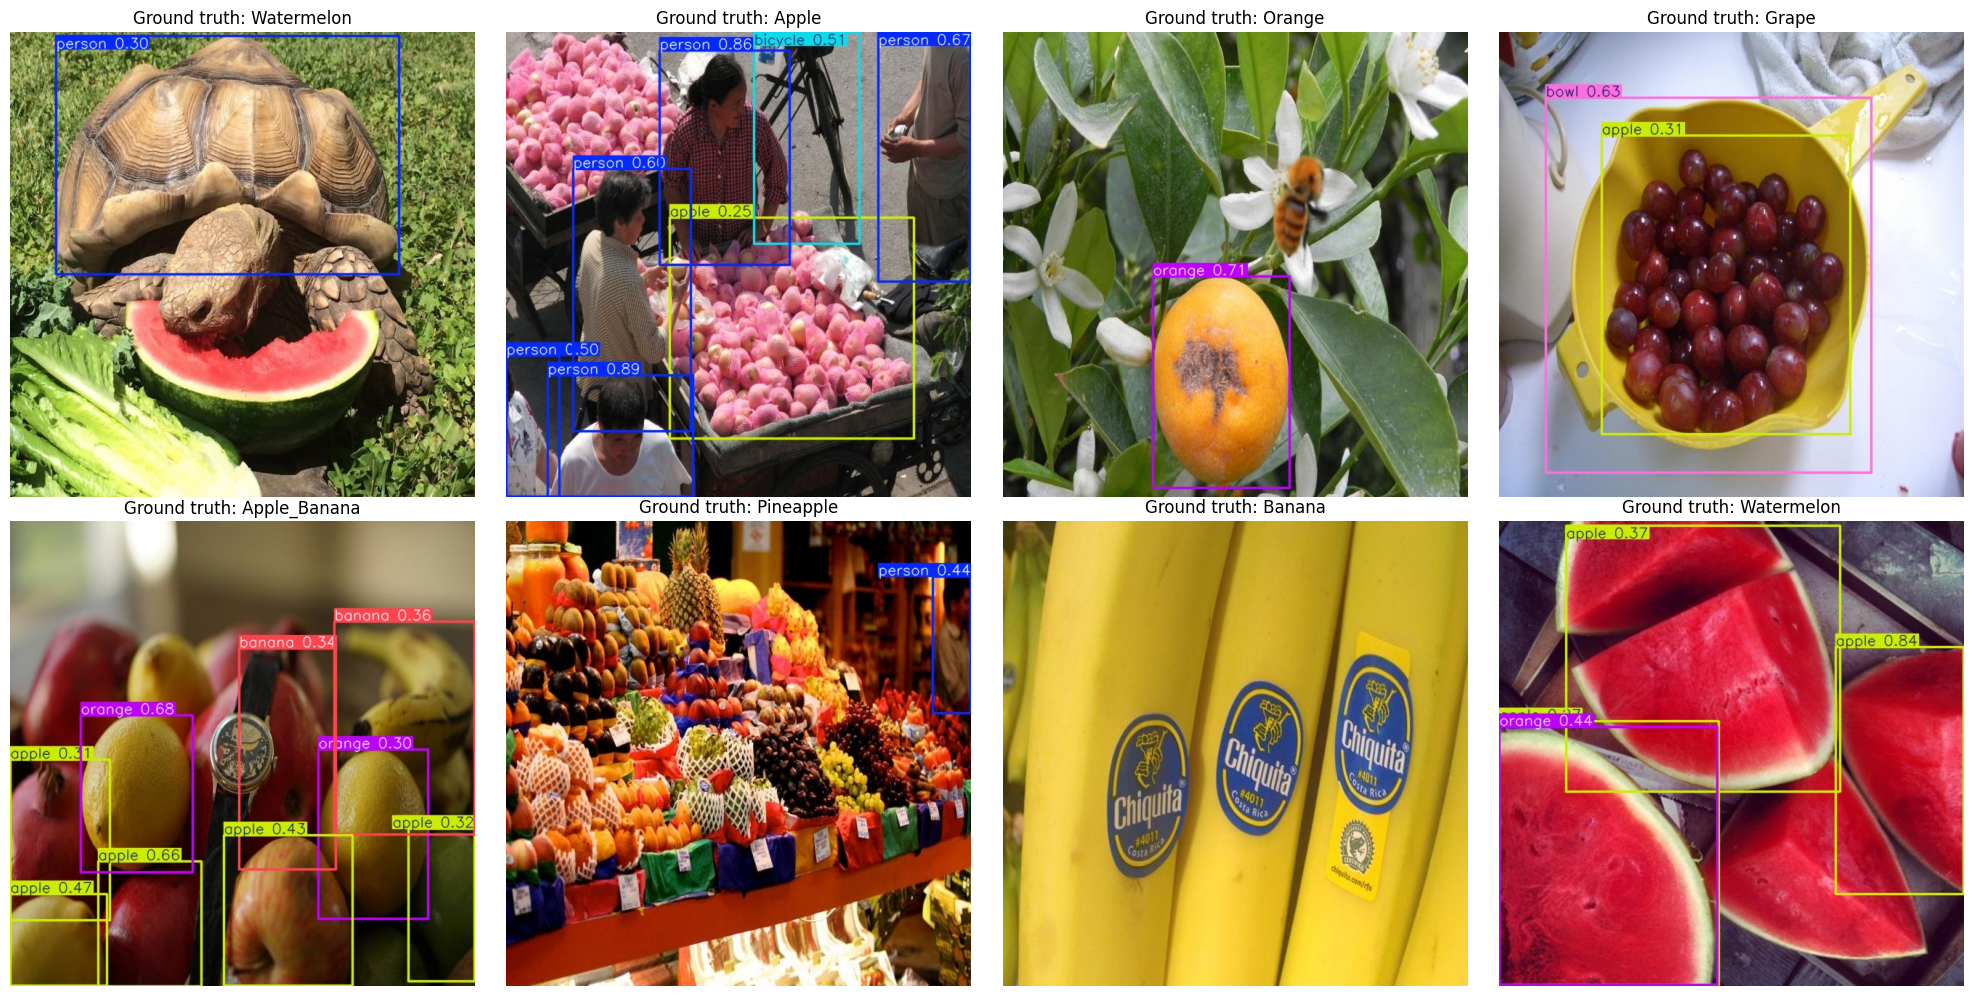

In [8]:
import matplotlib.pyplot as plt
from PIL import Image

pred_dir = Path(results[0].save_dir)
print("Annotated images saved to:", pred_dir)
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

for ax, item in zip(axes.flatten(), summary):
    img = Image.open(pred_dir / item["image"])
    ax.imshow(img)
    ax.set_title(f'Ground truth: {item["ground_truth"]}', fontsize=12)
    ax.axis("off")

plt.tight_layout()
plt.savefig(pred_dir / "comparison_grid.jpg", dpi=100, bbox_inches="tight")
plt.show()

## 11. What Objects Were Detected

Across the 8 sample images, the pre-trained COCO model detected:

In [9]:
from collections import Counter

class_counts = Counter()
zero_detections = 0
for item in summary:
    if not item["detections"]:
        zero_detections += 1
    for det in item["detections"]:
        class_counts[det["class"]] += 1

print("Detected class counts:", dict(class_counts))
print(f"Images with zero detections: {zero_detections}/{len(summary)}")

Detected class counts: {'person': 7, 'bicycle': 1, 'apple': 10, 'orange': 4, 'bowl': 1, 'banana': 2}
Images with zero detections: 1/8


| Image (ground-truth fruit) | Model's detections |
|---|---|
| Apple | person ×5, bicycle, apple (0.25) — apple detected but at low confidence, buried among people/bicycle in the scene |
| Apple + Banana | orange (0.68), apple ×5, banana ×2 — most fruits correctly found |
| Grape | bowl (0.63), apple (0.31) — **grape missed entirely** |
| Orange | orange (0.71) — correctly detected |
| Pineapple | person (0.44) — **pineapple missed entirely**, false "person" |
| Watermelon | person (0.30) — **watermelon missed entirely** |
| Banana | *no detections* — **banana missed entirely** |
| Watermelon | apple ×3, orange (0.44) — **watermelon misclassified as apples/orange** |

## 12. Observations

- **The out-of-the-box COCO model only "knows" 3 of the dataset's 6 fruits**
  (apple, banana, orange), because those are the only fruit classes in COCO's
  80-class vocabulary. Grape, pineapple, and watermelon have **no matching
  COCO class**, so the model either misses them completely or misclassifies
  them as the closest-looking known class (e.g., a watermelon slice being read
  as "apple"/"orange" due to similar round shape and color).
- **Apples and oranges were detected reliably** when clearly visible and
  reasonably sized in the frame, with confidences from ~0.25 up to 0.84.
- **Cluttered/multi-object scenes were harder**: the fruit-stall image full of
  people and a bicycle correctly detected people and the bicycle, but only
  found one apple at low confidence — small, overlapping fruit in a busy
  background is a common failure mode for a general-purpose model that wasn't
  trained specifically for this dataset.
- **False positives on unseen classes**: for pineapple and watermelon images,
  the model output a low-confidence "person" detection instead of the actual
  fruit — a sign the model is trying to fit the object to its known 80 classes
  rather than truly "not detecting."
- **Takeaway**: a pre-trained COCO model is a fast, zero-effort way to get
  partial fruit detection, but for reliable detection of all 6 classes
  (especially grape, pineapple, watermelon) the model would need to be
  **fine-tuned on this dataset**, e.g.:
  ```python
  model.train(data=f"{DATASET_DIR}/data.yaml", epochs=50, imgsz=640)
  ```
  rather than used purely off-the-shelf.
